In [1]:
import networkx as nx
import heapq
import time
from scipy.io import mmread
import matplotlib.pyplot as plt




==========================
Load Graph
==========================


In [2]:

def load_graph(file_path):

    if file_path.endswith(".mtx"):

        matrix = mmread(file_path)

        G = nx.from_scipy_sparse_array(matrix)

    elif file_path.endswith(".edges"):

        G = nx.Graph()

        with open(file_path, "r") as file:

            for line in file:

                if line.startswith("%"):
                    continue

                parts = line.split()

                if len(parts) >= 2:

                    u = int(parts[0])
                    v = int(parts[1])

                    G.add_edge(u, v)

    else:
        raise ValueError(f"Unsupported file format: {file_path}")

    return G




In [3]:
class HubLabeling:

    def __init__(self, graph, max_hubs=10):
        self.graph = graph
        self.max_hubs = max_hubs

        # each node stores: {hub: distance}
        self.labels = {}

        # selected hubs (highest degree nodes = realistic heuristic)
        self.hubs = sorted(
            graph.nodes(),
            key=lambda x: graph.degree(x),
            reverse=True
        )[:max_hubs]

    def preprocess(self):
        for hub in self.hubs:
            distances = nx.single_source_dijkstra_path_length(
                self.graph,
                hub
            )
            self.labels[hub] = distances

    def query(self, source, target):
        best = float("inf")

        for hub in self.hubs:
            if (
                hub in self.labels
                and source in self.labels[hub]
                and target in self.labels[hub]
            ):
                cost = (
                    self.labels[hub][source]
                    + self.labels[hub][target]
                )
                best = min(best, cost)

        return best

==========================
DATASETS
==========================


In [4]:

datasets = [
    "inf-USAir97.mtx",
    "inf-power.mtx",
    "road-roadNet-CA.mtx",
    "road-euroroad.edges"
]




==========================
MAIN
==========================


In [5]:

if __name__ == "__main__":

    print("\n===== HUB LABELING RESULTS =====\n")

    dataset_names = []
    preprocessing_times = []
    query_times = []
    node_counts = []
    edge_counts = []

    for dataset in datasets:

        print("=" * 60)
        print("Dataset:", dataset)

        G = load_graph(dataset)

        print("Nodes:", G.number_of_nodes())
        print("Edges:", G.number_of_edges())

        hl = HubLabeling(G, max_hubs=10)




===== HUB LABELING RESULTS =====

Dataset: inf-USAir97.mtx
Nodes: 332
Edges: 2126
Dataset: inf-power.mtx
Nodes: 4941
Edges: 6594
Dataset: road-roadNet-CA.mtx
Nodes: 1957027
Edges: 2760388
Dataset: road-euroroad.edges
Nodes: 1174
Edges: 1417


==========================
PREPROCESSING TIME
==========================


In [6]:
        start = time.perf_counter()

        hl.preprocess()

        end = time.perf_counter()

        prep_time = end - start

        print("Preprocessing Time:", round(prep_time, 6), "seconds")




Preprocessing Time: 0.044132 seconds


==========================
QUERY TEST
==========================


In [7]:
        nodes = list(G.nodes())

        source = nodes[0]
        target = nodes[-1]

        q_start = time.perf_counter()

        result = hl.query(source, target)

        q_end = time.perf_counter()

        q_time = q_end - q_start

        print("Approx Distance:", result)
        print("Query Time:", round(q_time, 6), "seconds")
        print()




Approx Distance: inf
Query Time: 8.4e-05 seconds



==========================
STORE RESULTS
==========================


In [8]:
        dataset_names.append(dataset)
        preprocessing_times.append(prep_time)
        query_times.append(q_time)
        node_counts.append(G.number_of_nodes())
        edge_counts.append(G.number_of_edges())




==========================
PREPROCESSING GRAPH
==========================


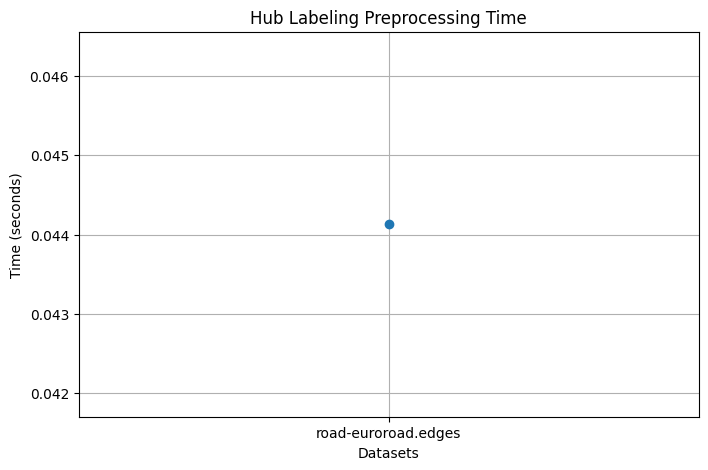

In [9]:

    plt.figure(figsize=(8, 5))
    plt.plot(dataset_names, preprocessing_times, marker="o")
    plt.title("Hub Labeling Preprocessing Time")
    plt.xlabel("Datasets")
    plt.ylabel("Time (seconds)")
    plt.grid()
    plt.savefig("hub_preprocessing.png")
    plt.show()




==========================
QUERY GRAPH (GPS PERFORMANCE)
==========================


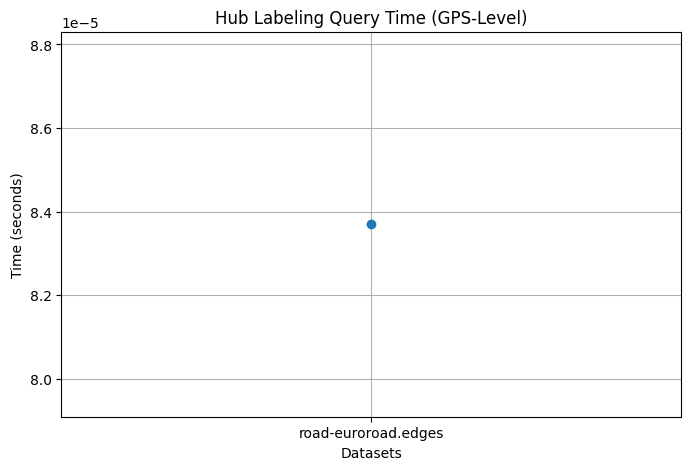

In [10]:

    plt.figure(figsize=(8, 5))
    plt.plot(dataset_names, query_times, marker="o")
    plt.title("Hub Labeling Query Time (GPS-Level)")
    plt.xlabel("Datasets")
    plt.ylabel("Time (seconds)")
    plt.grid()
    plt.savefig("hub_query_time.png")
    plt.show()




==========================
NODE GROWTH
==========================


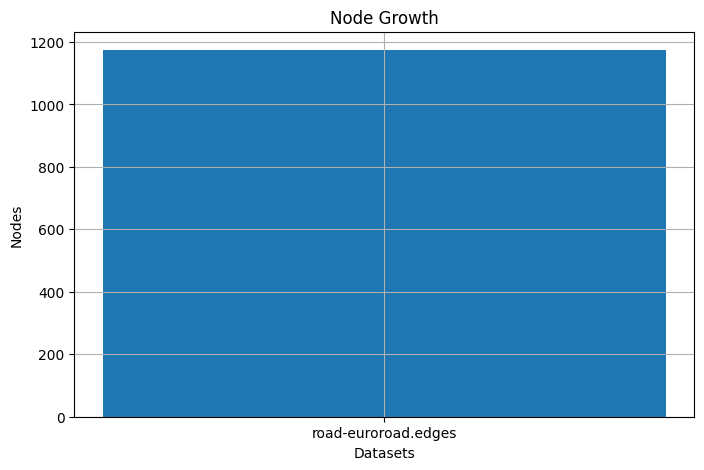

In [11]:

    plt.figure(figsize=(8, 5))
    plt.bar(dataset_names, node_counts)
    plt.title("Node Growth")
    plt.xlabel("Datasets")
    plt.ylabel("Nodes")
    plt.grid()
    plt.savefig("hub_node_growth.png")
    plt.show()




==========================
EDGE GROWTH
==========================


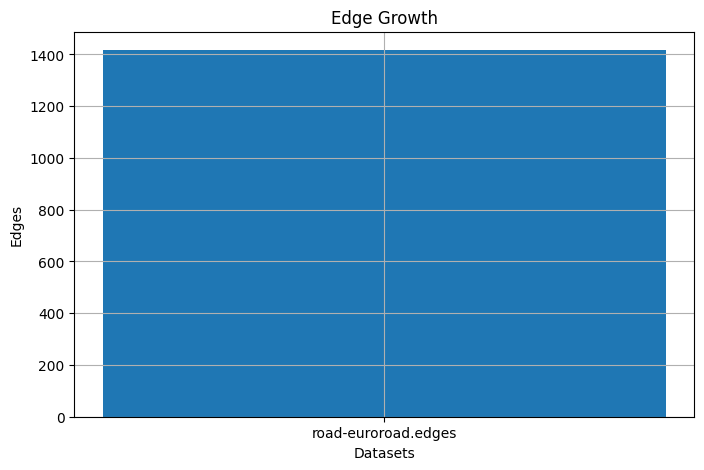

In [12]:

    plt.figure(figsize=(8, 5))
    plt.bar(dataset_names, edge_counts)
    plt.title("Edge Growth")
    plt.xlabel("Datasets")
    plt.ylabel("Edges")
    plt.grid()
    plt.savefig("hub_edge_growth.png")
    plt.show()
